# 03 — Benchmarks : le score à battre

## Objectif

Avant de construire des modèles, je calcule trois **benchmarks** : des prévisions très simples,
**sans apprentissage**, qui recopient le passé de la consommation. Ils donnent **le score à
battre** : un modèle qui ne fait pas mieux qu'eux ne sert à rien.

Le sujet demande *« au moins deux références simples »*, et donne des exemples : le jour
précédent, le même jour de la semaine précédente, la moyenne de jours comparables, un modèle
linéaire simple. Je fais les trois premiers ici. Le quatrième (régression calendrier + retards)
sera notre premier modèle appris, M1.

## Pourquoi je peux les faire dès maintenant

Un benchmark **n'apprend rien** : il recopie la consommation des jours précédents. Il n'a
besoin **que de la consommation** (prête depuis le notebook 01), ni de la météo ni du
calendrier. Les outils écrits ici (la façon de noter, la vérification de la règle des 14 h)
serviront ensuite tels quels pour les modèles.

## Les étapes de ce notebook

1. Ranger la consommation par jour et par heure de Paris
2. Les trois benchmarks : B0, B1 et B2
3. Vérifier la règle des 14 h (aucune triche)
4. La façon de noter les prévisions
5. Les résultats sur l'apprentissage (2016-2022) et la validation (2023)
6. Où les benchmarks se trompent, et ce que ça nous apprend pour les modèles

**Le test 2024-2025 n'est pas utilisé ici** : il ne servira qu'une seule fois, à la fin, après
avoir gelé tous nos choix. Le code refuse d'ailleurs de le calculer.

## Où est le code ?

- `src/benchmarks.py` : les trois benchmarks et la vérification de la règle des 14 h ;
- `src/evaluation.py` : les mesures d'erreur, les mêmes pour toutes les méthodes ;
- `tests/test_benchmarks.py` et `tests/test_evaluation.py` : les tests automatiques.

Ce notebook appelle ces fonctions et explique les résultats. Relancer sans le notebook :
`python -m src.benchmarks`.

In [1]:
import sys
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Je cherche la racine du projet (le dossier qui contient "src") pour pouvoir importer le code
RACINE = Path.cwd().resolve()
while not (RACINE / "src").exists() and RACINE != RACINE.parent:
    RACINE = RACINE.parent
sys.path.insert(0, str(RACINE))

from src import benchmarks, config, evaluation, rte

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


def voir_code(fonction):
    """Affiche le code d'une fonction de src/, pour le lire sans quitter le notebook."""
    print(inspect.getsource(fonction))


# La vraie consommation en encre foncée ; une couleur fixe par benchmark, dans tous les graphiques.
REEL, VERT, BLEU, ORANGE = "#2b3440", "#1baf7a", "#2a78d6", "#eb6834"
COULEURS = {"B0": VERT, "B1": BLEU, "B2": ORANGE}
GRIS_TEXTE = "#52514e"
plt.rcParams.update({
    "figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": GRIS_TEXTE, "xtick.color": GRIS_TEXTE,
    "ytick.color": GRIS_TEXTE, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.titleweight": "bold", "axes.titlesize": 12, "lines.linewidth": 1.5,
})

conso_h = rte.lire_prepare()  # le fichier préparé dans le notebook 01
print(f"{len(conso_h):,} heures de consommation chargées")

88,416 heures de consommation chargées


## 1. Ranger la consommation par jour et par heure de Paris

**Pourquoi :** le problème est posé en heure de Paris (« les 24 heures de demain »). Pour
recopier « mercredi dernier à 18 h », le plus simple est un tableau avec **une ligne par jour**
et **une colonne par heure** (0 à 23).

**Les jours de changement d'heure** n'ont pas 24 heures :
- dernier dimanche de mars : **23 h**, l'heure 2 n'existe pas → sa case reste vide ;
- dernier dimanche d'octobre : **25 h**, l'heure 2 existe deux fois → je fais la moyenne des deux.

In [2]:
voir_code(benchmarks.consommation_par_jour)

def consommation_par_jour(conso_h):
    """Range la consommation horaire en tableau : une ligne par jour, une colonne par heure.

    Les jours et les heures sont ceux de Paris, car le problème est posé en heure locale.
    Jours de changement d'heure :
    - jour de 23 h (mars) : l'heure 2 n'existe pas, sa case reste vide ;
    - jour de 25 h (octobre) : l'heure 2 existe deux fois, je fais la moyenne des deux.
    """
    paris = conso_h.index.tz_convert(config.FUSEAU)
    tableau = (
        pd.DataFrame({
            "date": pd.to_datetime(paris.date),
            "heure": paris.hour,
            "consommation_MW": conso_h["consommation_MW"].to_numpy(),
        })
        .pivot_table(index="date", columns="heure", values="consommation_MW", aggfunc="mean")
        .reindex(columns=HEURES)
    )
    tableau.columns.name = "heure"
    return tableau



In [3]:
conso_jour = benchmarks.consommation_par_jour(conso_h)
print(f"{conso_jour.shape[0]} jours x {conso_jour.shape[1]} heures")

# Exemple : la semaine du passage à l'heure d'été 2023 (le dimanche 26 mars, l'heure 2 est vide)
(conso_jour.loc["2023-03-24":"2023-03-28", 0:5] / 1000).round(1)

3684 jours x 24 heures


heure,0,1,2,3,4,5
date,,,,,,
2023-03-24,47.8,45.0,44.9,42.8,41.4,42.4
2023-03-25,49.7,47.0,46.8,44.4,42.6,42.6
2023-03-26,47.3,44.8,NaN,44.9,42.3,40.5
2023-03-27,49.2,46.6,46.7,44.9,43.6,45.0
2023-03-28,54.1,51.1,51.4,50.0,48.9,50.0


## 2. Les trois benchmarks

On veut prévoir le jour cible J+1. Exemple : le **mercredi 11 janvier 2023**, la prévision
étant faite le **mardi 10 janvier à 14 h**.

| Benchmark | Idée | Ce qu'il recopie pour le mercredi 11/01/2023 |
|---|---|---|
| **B0** « veille effective » | demain ressemblera à aujourd'hui | heures 0 à 12 : **mardi 10** ; heures 13 à 23 : **lundi 9** |
| **B1** « semaine précédente » | demain ressemblera au même jour de la semaine dernière | le mercredi 4 janvier |
| **B2** « moyenne de 4 semaines » | pareil, en moyenne sur 4 semaines | moyenne des mercredis 4 janvier, 28, 21 et 14 décembre |

**Le piège de B0 et la règle des 14 h :** la « veille » du mercredi, c'est le mardi. Mais à
14 h le mardi, on ne connaît le mardi que **jusqu'à 13 h** (dernière tranche connue : 12 h-13 h).
Pour les heures **13 à 23**, recopier le mardi serait de la triche : ces heures n'ont pas encore
eu lieu. B0 prend donc le **lundi** pour ces heures-là.

**Pourquoi ces trois-là :**
- **B0** suit les changements les plus récents (le froid d'hier), mais mélange les types de jours
  (pour un lundi, il recopie un dimanche et un samedi) ;
- **B1** respecte le type de jour (un mercredi pour un mercredi), mais regarde une semaine en arrière ;
- **B2** est plus stable que B1 (un jour bizarre pèse 4 fois moins), mais réagit encore plus lentement.

In [4]:
# B0 : de combien de jours je recule, selon l'heure prévue
print("Recul (en jours avant le jour cible) pour chaque heure, B0 :")
print(benchmarks.DECALAGES_B0)
voir_code(benchmarks.moyenne_des_jours_precedents)

Recul (en jours avant le jour cible) pour chaque heure, B0 :
{0: [1], 1: [1], 2: [1], 3: [1], 4: [1], 5: [1], 6: [1], 7: [1], 8: [1], 9: [1], 10: [1], 11: [1], 12: [1], 13: [2], 14: [2], 15: [2], 16: [2], 17: [2], 18: [2], 19: [2], 20: [2], 21: [2], 22: [2], 23: [2]}
def moyenne_des_jours_precedents(conso_jour, jours_cibles, decalages):
    """Pour chaque heure H, moyenne de l'heure H des jours situés `decalages` jours avant.

    `decalages` est une liste (la même pour toutes les heures, ex. [7]) ou un dict
    {heure: liste} quand le recul dépend de l'heure (B0).
    Si une valeur manque pour un des jours (heure 2 d'un jour de 23 h), je fais la moyenne
    des valeurs disponibles. Si toutes manquent, la case reste vide.
    """
    jours_cibles = pd.DatetimeIndex(jours_cibles)
    prevision = pd.DataFrame(index=jours_cibles, columns=HEURES, dtype=float)
    prevision.columns.name = "heure"
    for heure, liste in _par_heure(decalages).items():
        copies = pd.concat(
            

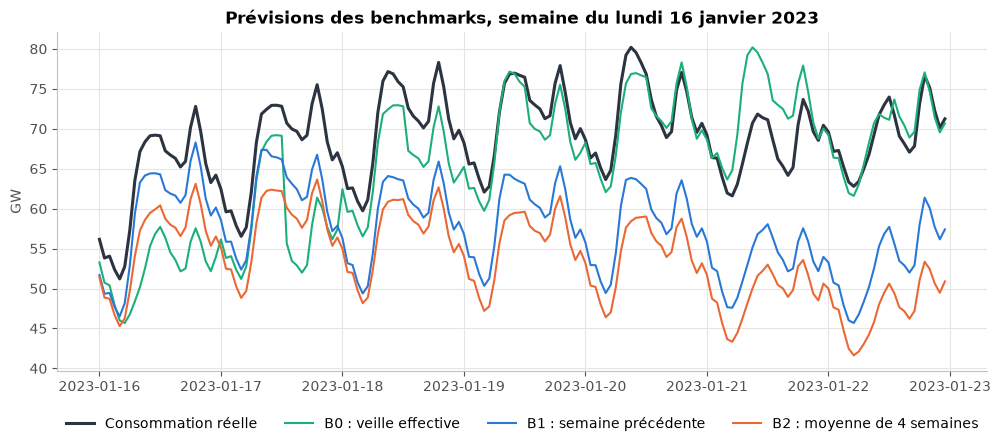

In [5]:
# La semaine du 16 au 22 janvier 2023 : une vague de froid arrive à partir du jeudi 19
jours = pd.date_range("2023-01-16", "2023-01-22", freq="D")
vrai = conso_jour.loc[jours]
prev_semaine = {
    "B0": benchmarks.benchmark_b0(conso_jour, jours),
    "B1": benchmarks.benchmark_b1(conso_jour, jours),
    "B2": benchmarks.benchmark_b2(conso_jour, jours),
}
noms = {"B0": "B0 : veille effective", "B1": "B1 : semaine précédente", "B2": "B2 : moyenne de 4 semaines"}


def en_courbe(tableau):
    """Remet un tableau jour x heure en une seule courbe horaire (pour le graphique)."""
    serie = tableau.stack()
    serie.index = [jour + pd.Timedelta(hours=heure) for jour, heure in serie.index]
    return serie / 1000


fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(en_courbe(vrai), color=REEL, linewidth=2.2, label="Consommation réelle")
for cle, prevision in prev_semaine.items():
    ax.plot(en_courbe(prevision), color=COULEURS[cle], label=noms[cle])
ax.set_ylabel("GW")
ax.set_title("Prévisions des benchmarks, semaine du lundi 16 janvier 2023")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4)
plt.show()

**Ce que je lis :**
- B1 et B2 reproduisent bien la **forme** de la journée, mais leur **niveau** est trop bas
  **toute la semaine** : la semaine précédente (9-15 janvier) était plus douce. L'écart se
  creuse à partir du **jeudi 19**, avec la vague de froid.
- **B0 suit beaucoup mieux le niveau** du mercredi au vendredi : il recopie la veille, qui a
  déjà connu le froid.
- Mais B0 se trompe quand **le type de jour change** : le **lundi 16**, il recopie le week-end
  et prévoit trop bas ; le **samedi 21**, il recopie le vendredi (un jour de travail) et
  prévoit trop haut.

Aucun benchmark ne voit venir le froid à l'avance : ils ne connaissent pas la température.

## 3. Vérifier la règle des 14 h

Je ne me contente pas de dire que les benchmarks respectent la règle : je le **vérifie** pour
chaque jour et **chaque heure**, avec la règle de `src/protocole.py`. C'est important pour B0,
qui recule de 1 jour pour les heures 0 à 12, et de 2 jours pour les heures 13 à 23.

In [6]:
voir_code(benchmarks.verifier_disponibilite)

def verifier_disponibilite(jours_cibles, decalages):
    """Vérifie, heure par heure, qu'aucun benchmark n'utilise une valeur inconnue à 14 h le jour J.

    Pour le jour cible et l'heure H, la prévision est faite la veille (jour J). La valeur
    recopiée la plus récente est l'heure H, `min(decalages[H])` jours avant le jour cible.
    Cette heure doit être terminée avant la fin des données connues à 14 h le jour J
    (src/protocole.py). S'arrête avec une erreur sinon.
    """
    jours_cibles = pd.DatetimeIndex(jours_cibles)
    # Fin des données connues à 14 h le jour J (= veille du jour cible), en UTC
    limites = pd.DatetimeIndex(
        [protocole.fin_des_donnees_connues(j) for j in jours_cibles - pd.Timedelta(days=1)]
    )
    for heure, liste in _par_heure(decalages).items():
        recul = min(liste)
        # Début de l'heure recopiée, en heure de Paris puis en UTC. Les heures qui n'existent
        # pas ou existent deux fois (changement d'heure) sont prises au plus tar

In [7]:
jours_2023 = benchmarks.jours_de_la_periode("validation")
for nom, decalages in [("B0", benchmarks.DECALAGES_B0), ("B1", benchmarks.DECALAGE_B1),
                       ("B2", benchmarks.DECALAGES_B2)]:
    benchmarks.verifier_disponibilite(jours_2023, decalages)
    print(f"{nom} : aucune valeur inconnue à 14 h n'est utilisée.")

# La vérification sait détecter une triche : une « vraie veille » qui recopierait le jour J
# aussi pour les heures 13 à 23 (ces heures n'ont pas encore eu lieu à 14 h).
try:
    benchmarks.verifier_disponibilite(jours_2023, [1])
except ValueError as erreur:
    print("\nTriche détectée :", erreur)

B0 : aucune valeur inconnue à 14 h n'est utilisée.
B1 : aucune valeur inconnue à 14 h n'est utilisée.
B2 : aucune valeur inconnue à 14 h n'est utilisée.

Triche détectée : Fuite : la prévision du 2023-01-01 à 13 h utilise le 2022-12-31 à 13 h, inconnu à 14 h le 2022-12-31


## 4. La façon de noter les prévisions

Pour chaque jour cible, je compare les 24 heures prévues aux 24 heures réelles. Le sujet
demande **plusieurs mesures complémentaires** :

| Mesure | Question | Unité |
|---|---|---|
| **MAE** | De combien se trompe-t-on en moyenne ? | MW |
| **RMSE** | Pareil, mais les grosses erreurs comptent plus | MW |
| **MAPE** | La MAE en pourcentage de la consommation | % |
| **Biais** | Prévoit-on trop (positif) ou pas assez (négatif) ? | MW |
| **Erreur énergie du jour** | A-t-on bien prévu le total de la journée ? | GWh |
| **Erreur pointe** | A-t-on bien prévu le maximum de la journée ? | MW |
| **Écart heure de pointe** | A-t-on trouvé la bonne heure du maximum ? | heures |

**Les mêmes jours pour tout le monde :** le sujet exige de comparer les méthodes **sur les
mêmes dates**. Un jour où une méthode n'a pas ses 24 valeurs est retiré pour **toutes** les
méthodes.

**Les jours de changement d'heure** (2 par an) sont retirés de la notation : ils n'ont pas
24 heures, on ne peut pas les comparer heure par heure (proposition pour la décision 11).

In [8]:
voir_code(evaluation.erreurs_par_jour)

def erreurs_par_jour(reel, prevu):
    """Calcule les mesures d'erreur pour chaque jour cible présent dans les deux tableaux."""
    jours = reel.index.intersection(prevu.index)
    r = reel.loc[jours, HEURES].to_numpy(dtype=float)
    p = prevu.loc[jours, HEURES].to_numpy(dtype=float)
    ecart = p - r  # positif = on prévoit trop

    return pd.DataFrame({
        "mae": np.abs(ecart).mean(axis=1),
        "rmse": np.sqrt((ecart ** 2).mean(axis=1)),
        "mape": (np.abs(ecart) / r).mean(axis=1) * 100,
        "biais": ecart.mean(axis=1),
        "erreur_energie": p.sum(axis=1) - r.sum(axis=1),
        "erreur_pointe": p.max(axis=1) - r.max(axis=1),
        "ecart_heure_pointe": np.abs(p.argmax(axis=1) - r.argmax(axis=1)),
    }, index=jours)



## 5. Les résultats

Je calcule les trois benchmarks sur l'**apprentissage** (2016-2022), pour information, et sur la
**validation** (2023). C'est la validation qui servira de référence pour choisir les modèles.

In [9]:
scores_validation, reel, previsions = benchmarks.evaluer_periode("validation", conso_h)
scores_apprentissage, reel_app, previsions_app = benchmarks.evaluer_periode("apprentissage", conso_h)

print("=== Validation 2023 ===")
scores_validation.round(1)

=== Validation 2023 ===


,B0 : veille effective,B1 : semaine précédente,B2 : moyenne de 4 semaines
nb_jours,361.0,361.0,361.0
MAE (MW),3312.7,3467.6,4162.4
RMSE (MW),4527.4,5009.2,5872.4
MAPE (%),6.7,6.5,7.9
biais (MW),-15.1,-33.9,23.1
"erreur énergie du jour (GWh, absolue)",75.7,80.6,96.9
"erreur pointe (MW, absolue)",3558.2,3795.9,4389.9
écart heure de pointe (h),1.8,1.8,1.5
heure de pointe exacte (% des jours),55.1,63.7,65.7


In [10]:
print("=== Apprentissage 2016-2022 (pour information) ===")
scores_apprentissage.round(1)

=== Apprentissage 2016-2022 (pour information) ===


,B0 : veille effective,B1 : semaine précédente,B2 : moyenne de 4 semaines
nb_jours,2529.0,2529.0,2529.0
MAE (MW),3724.8,3559.4,4176.8
RMSE (MW),5196.3,5190.5,5733.2
MAPE (%),7.1,6.4,7.6
biais (MW),-22.5,-10.8,-49.4
"erreur énergie du jour (GWh, absolue)",85.1,82.5,97.6
"erreur pointe (MW, absolue)",3912.1,3706.7,4310.2
écart heure de pointe (h),2.9,2.6,2.3
heure de pointe exacte (% des jours),48.9,61.6,61.4


**Ce que je lis :**
- **En 2023, B0 a la plus petite erreur moyenne** (MAE ≈ 3 310 MW) et la plus petite RMSE
  (≈ 4 530 MW), devant B1 (≈ 3 470 MW et ≈ 5 010 MW).
- **Mais B1 fait mieux sur d'autres mesures** : un pourcentage d'erreur (MAPE) un peu plus
  faible, et surtout il trouve **plus souvent la bonne heure de pointe** (64 % des jours contre
  55 % pour B0).
- **Et sur 2016-2022, c'est B1 qui gagne** en MAE (≈ 3 560 contre ≈ 3 720 MW).
- **B2 est le moins bon partout.**

**Le classement B0 / B1 dépend de l'année et de la mesure.** C'est exactement le genre de
résultat que le sujet demande de discuter (« stabilité du classement des modèles selon les
périodes et les métriques »). Le premier modèle devra donc battre **les deux**.

Le biais est presque nul pour tous : sur l'année, les benchmarks ne se trompent pas toujours
dans le même sens. 361 jours sur 365 sont notés : les 2 jours de changement d'heure, plus 2
jours où un benchmark n'a pas ses 24 heures (il recopie le dimanche de 23 h).

## 6. Où les benchmarks se trompent, et ce que ça nous apprend

Les erreurs des benchmarks montrent ce que les modèles devront mieux faire.

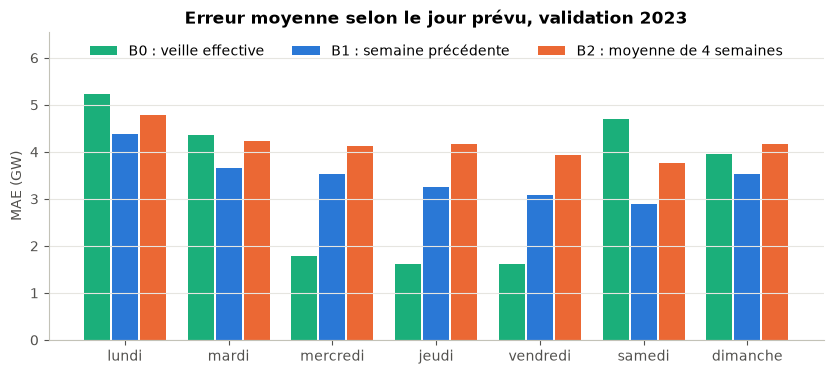

In [11]:
jours = evaluation.jours_comparables(reel, *previsions.values())
erreurs = {nom.split(" :")[0]: evaluation.erreurs_par_jour(reel.loc[jours], p.loc[jours])
           for nom, p in previsions.items()}

# Erreur moyenne selon le jour de la semaine du jour cible
par_jour = pd.DataFrame({cle: e["mae"].groupby(e.index.dayofweek).mean() for cle, e in erreurs.items()}) / 1000

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(7)
for i, cle in enumerate(["B0", "B1", "B2"]):
    ax.bar(x + (i - 1) * 0.27, par_jour[cle], width=0.25, color=COULEURS[cle], label=noms[cle])
ax.set_xticks(x, ["lundi", "mardi", "mercredi", "jeudi", "vendredi", "samedi", "dimanche"])
ax.set_ylabel("MAE (GW)")
ax.set_title("Erreur moyenne selon le jour prévu, validation 2023")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, ncol=3, loc="upper center")
ax.set_ylim(0, par_jour.max().max() * 1.25)
plt.show()

**Ce que je lis, et c'est la clé de B0 :**
- **Du mercredi au vendredi, B0 est de loin le meilleur** (environ 1,6 à 1,8 GW d'erreur,
  deux fois moins que B1). Il recopie la veille, qui est un jour du même type (un jour de
  travail) et qui a connu la même météo.
- **Le lundi, le mardi, le samedi et le dimanche, B0 est le pire.** Il recopie un jour d'un
  autre type :
  - pour un **lundi**, il recopie le dimanche (matin) et le samedi (après-midi) ;
  - pour un **mardi**, l'après-midi vient du dimanche ;
  - pour un **samedi**, il recopie un vendredi, qui est un jour de travail ;
  - pour un **dimanche**, il recopie le samedi et le vendredi.
- **B1** a une erreur à peu près égale tous les jours : il compare toujours un jour au même
  jour de la semaine.

**Conclusion pour les modèles :** il faut **combiner** les deux idées. Le niveau récent vient de
B0 (la veille, et en particulier le matin du jour J). La forme de la semaine vient de B1 (le même
jour, une semaine avant), ou du **calendrier** (le jour de la semaine). C'est exactement ce que
fera la régression M1 avec les retards de 48 h et 168 h et le jour de la semaine.

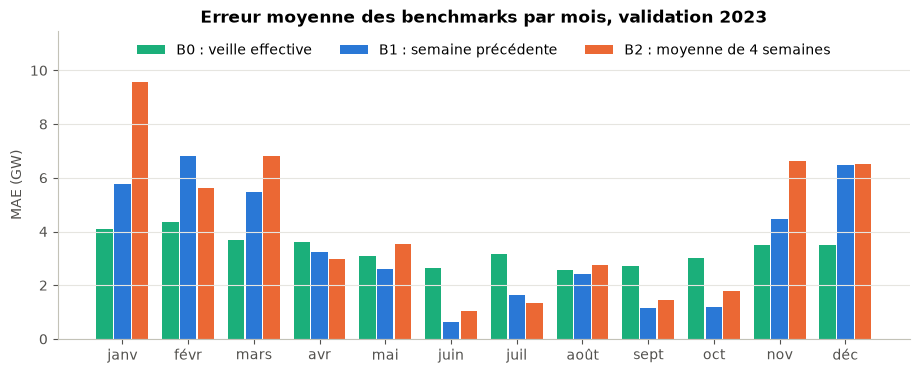

In [12]:
# Erreur moyenne par mois
par_mois = pd.DataFrame({cle: e["mae"].groupby(e.index.month).mean() for cle, e in erreurs.items()}) / 1000

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(12)
for i, cle in enumerate(["B0", "B1", "B2"]):
    ax.bar(x + (i - 1) * 0.27, par_mois[cle], width=0.25, color=COULEURS[cle], label=noms[cle])
ax.set_xticks(x, ["janv", "févr", "mars", "avr", "mai", "juin",
                  "juil", "août", "sept", "oct", "nov", "déc"])
ax.set_ylabel("MAE (GW)")
ax.set_title("Erreur moyenne des benchmarks par mois, validation 2023")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, ncol=3, loc="upper center")
ax.set_ylim(0, par_mois.max().max() * 1.2)
plt.show()

**Ce que je lis :**
- **L'hiver, B0 est nettement meilleur** que B1 et B2 (environ 4 GW contre 6 à 7 GW en janvier
  et février). En hiver, la consommation suit le **froid**, qui change d'un jour à l'autre :
  recopier la veille suit mieux le froid que recopier la semaine dernière.
- **L'été, B1 est meilleur** (moins de 1 GW en juin). La météo change peu et ne joue presque pas
  sur la consommation : c'est la **forme de la semaine** qui compte, et B0 la rate le lundi et le
  week-end.
- **B2 est en retard sur les saisons.** En novembre, quand il fait de plus en plus froid, la
  moyenne des 4 semaines précédentes regarde des semaines plus douces : B2 prévoit trop bas.
- **L'hiver reste la saison la plus difficile pour tous** : c'est là que la **température**
  devrait apporter le plus aux modèles.

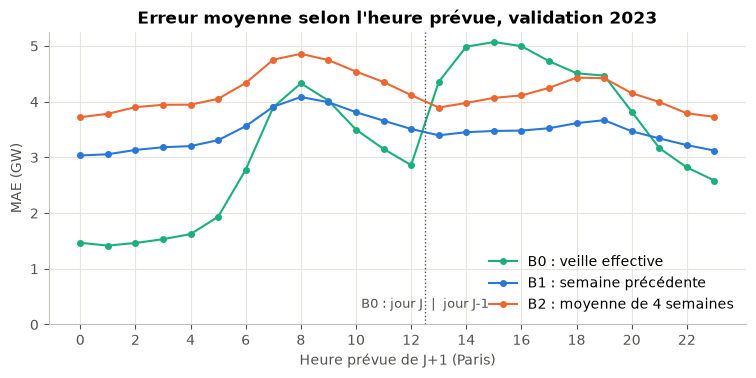

In [13]:
# Erreur moyenne selon l'heure de la journée prévue
ecart_heure = pd.DataFrame({
    nom.split(" :")[0]: (p.loc[jours] - reel.loc[jours]).abs().mean() / 1000
    for nom, p in previsions.items()
})
fig, ax = plt.subplots(figsize=(9, 3.8))
for cle in ["B0", "B1", "B2"]:
    ax.plot(ecart_heure.index, ecart_heure[cle], color=COULEURS[cle], marker="o", markersize=4,
            label=noms[cle])
ax.axvline(12.5, color=GRIS_TEXTE, linewidth=1, linestyle=":")
ax.annotate("B0 : jour J  |  jour J-1", (12.5, 0.3), ha="center", fontsize=9, color=GRIS_TEXTE)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Heure prévue de J+1 (Paris)")
ax.set_ylabel("MAE (GW)")
ax.set_ylim(bottom=0)
ax.set_title("Erreur moyenne selon l'heure prévue, validation 2023")
ax.legend(frameon=False, loc="lower right")
plt.show()

**Ce que je lis :**
- Pour **B1 et B2**, les erreurs sont plus grandes **le matin, vers 7-9 h**, quand la
  consommation monte vite (réveil, chauffage), avec une deuxième bosse vers **18-19 h**.
- **B0 est excellent la nuit** (environ 1,5 GW d'erreur de 0 h à 5 h) : la nuit, la
  consommation dépend peu du type de jour, et le niveau récent suffit.
- **Pour B0, l'erreur saute à 13 h** et culmine vers **14-16 h** (environ 5 GW) : à partir de
  13 h, il recopie le jour J-1 au lieu du jour J, une information plus ancienne d'un jour.
  **C'est le coût de la règle des 14 h**, visible directement sur le graphique.

In [14]:
# Les jours où B0 et B1 se sont le plus trompés en 2023
for cle in ["B0", "B1"]:
    pires = erreurs[cle].sort_values("mae", ascending=False).head(8)
    print(f"\n{noms[cle]} : les 8 pires jours")
    print(pd.DataFrame({
        "jour": pires.index.strftime("%A %d/%m/%Y"),
        "MAE (MW)": pires["mae"].round(0).astype(int),
        "biais (MW)": pires["biais"].round(0).astype(int),
    }).to_string(index=False))


B0 : veille effective : les 8 pires jours
              jour  MAE (MW)  biais (MW)
 Monday 27/02/2023     11713      -11713
 Monday 16/01/2023     10904      -10904
Tuesday 03/01/2023     10468      -10468
 Monday 09/01/2023      9158       -9158
Tuesday 17/01/2023      9006       -9006
 Monday 06/02/2023      8677       -8677
 Monday 18/12/2023      8630       -8630
 Sunday 12/03/2023      8417        8417

B1 : semaine précédente : les 8 pires jours
               jour  MAE (MW)  biais (MW)
  Monday 25/12/2023     19175       19175
  Sunday 22/01/2023     15898      -15898
Saturday 21/01/2023     14264      -14264
 Tuesday 26/12/2023     14067       14067
  Friday 20/01/2023     13866      -13866
  Monday 13/03/2023     13051       13051
 Tuesday 28/02/2023     12653      -12653
Thursday 19/01/2023     12180      -12180


**Ce que je lis :**
- **B1** se trompe surtout à cause du **calendrier** (le **lundi 25 décembre**, Noël : il recopie
  un lundi de travail et prévoit environ 19 000 MW de trop) et de la **météo** (vague de froid
  du **19 au 23 janvier** : il recopie une semaine plus douce et prévoit trop bas).
- **B0** se trompe surtout les **lundis et mardis d'hiver** : il recopie un week-end, où l'on
  consomme moins, et prévoit trop bas (par exemple le lundi 27 février, le lundi 16 janvier,
  le mardi 3 janvier, au retour des vacances de Noël).

Les deux causes, **météo** et **calendrier**, sont exactement les deux informations que les
modèles auront en plus. Ces journées sont de bonnes candidates pour l'**analyse des échecs**
demandée par le sujet (au moins trois journées expliquées).

In [15]:
# Le classement B0 / B1 est-il stable d'une année à l'autre ?
jours_app = evaluation.jours_comparables(reel_app, *previsions_app.values())
mae_par_an = pd.DataFrame({
    nom.split(" :")[0]: evaluation.erreurs_par_jour(reel_app.loc[jours_app], p.loc[jours_app])["mae"]
    for nom, p in previsions_app.items()
}).groupby(lambda jour: jour.year).mean()
mae_par_an.loc[2023] = [erreurs[c]["mae"].mean() for c in mae_par_an.columns]
mae_par_an["meilleur"] = mae_par_an.idxmin(axis=1)
mae_par_an.round(0)

,B0,B1,B2,meilleur
2016,3942.0,3378.0,3939.0,B1
2017,3894.0,3587.0,4557.0,B1
2018,3968.0,4066.0,4102.0,B0
2019,3938.0,3320.0,4065.0,B1
2020,3427.0,3138.0,3715.0,B1
2021,3567.0,3972.0,4358.0,B0
2022,3338.0,3456.0,4503.0,B0
2023,3313.0,3468.0,4162.0,B0


**Ce que je lis :** le meilleur benchmark **change selon l'année** : B1 gagne en 2016, 2017,
2019 et 2020 ; B0 gagne en 2018, 2021, 2022 et 2023. Les deux sont proches. Le classement n'est
donc **pas stable** : c'est une raison de plus pour exiger qu'un modèle batte **les deux**, et
pour regarder ses résultats année par année.

## Résumé

| Question | Réponse |
|---|---|
| Benchmarks calculés | **B0** (veille effective), **B1** (semaine précédente), **B2** (moyenne de 4 semaines) |
| **Score à battre (validation 2023)** | **B0 : MAE ≈ 3 310 MW**, RMSE ≈ 4 530 MW ; **B1 : MAE ≈ 3 470 MW**, MAPE 6,5 %, heure de pointe exacte 64 % des jours |
| Le meilleur benchmark | **Dépend de l'année et de la mesure** : B0 en hiver et en milieu de semaine, B1 en été, le lundi et le week-end |
| Quand les benchmarks échouent | En **hiver** (le froid change), aux **jours fériés** (Noël), aux **changements de type de jour** (lundi, week-end) |
| Ce que les modèles devront apporter | Le **niveau récent** (comme B0) + la **forme de la semaine** (comme B1) + la **température** + le **calendrier** |
| Règle des 14 h | Vérifiée pour chaque jour et chaque heure : aucune triche |
| Test 2024-2025 | **Pas utilisé**, protégé par le code |

**Prochaine étape :** le premier modèle appris (M1 : régression avec le calendrier et les
retards de consommation de 48 h et 168 h), qui devra battre B0 et B1 sur 2023.